In [7]:
from OptimalBattery import simulate as sim
import numpy as np
import matplotlib.pyplot as plt
import HierarchBayesParcel.evaluation as ev
import torch as pt
import OptimalBattery.util as ut
from numpy.linalg import eigh
from scipy.stats import pearsonr
from Functional_Fusion.dataset import DataSetMDTB
import PcmPy as pcm
import seaborn as sns
import os
import pandas as pd
import pickle
from HierarchBayesParcel.util import indicator
import HierarchBayesParcel.emissions as em
import HierarchBayesParcel.full_model as fm
from IndividualParcellation.evaluate import calc_test_dcbc
from DCBC.utilities import compute_dist
import Functional_Fusion.atlas_map as am
from HierarchBayesParcel.evaluation import calc_test_error

In [2]:
a,_= am.get_atlas(atlas_str='MNISymC2')
dist = compute_dist(a.world.T, resolution=1)


# MDTB Vs

In [3]:
# mdtb vs based on HBP
model_dir = 'Y:/data/Cerebellum/ProbabilisticParcellationModel/Models'
if not os.path.exists(model_dir):
    model_dir = '/cifs/diedrichsen/data/Cerebellum/ProbabilisticParcellationModel/Models'
    
model_name = f'/Models_03/NettekovenSym32_space-MNISymC2'
fname = model_dir + model_name
with open(fname + '.pickle', 'rb') as file:
        full_model = pickle.load(file)[0]

# load emission model & Vs for mdtb ses-1
mdtb_1_emission = full_model.emissions[0]
mdtb_1_Vs = mdtb_1_emission.V

#make into np array
VL_mdtb = mdtb_1_Vs.detach().numpy()
GL_mdtb = VL_mdtb @ VL_mdtb.T

mdtb_2_emission = full_model.emissions[1]
mdtb_2_Vs = mdtb_2_emission.V

#make into np array
VL_mdtb_2 = mdtb_2_Vs.detach().numpy()
GL_mdtb_2 = VL_mdtb_2 @ VL_mdtb_2.T

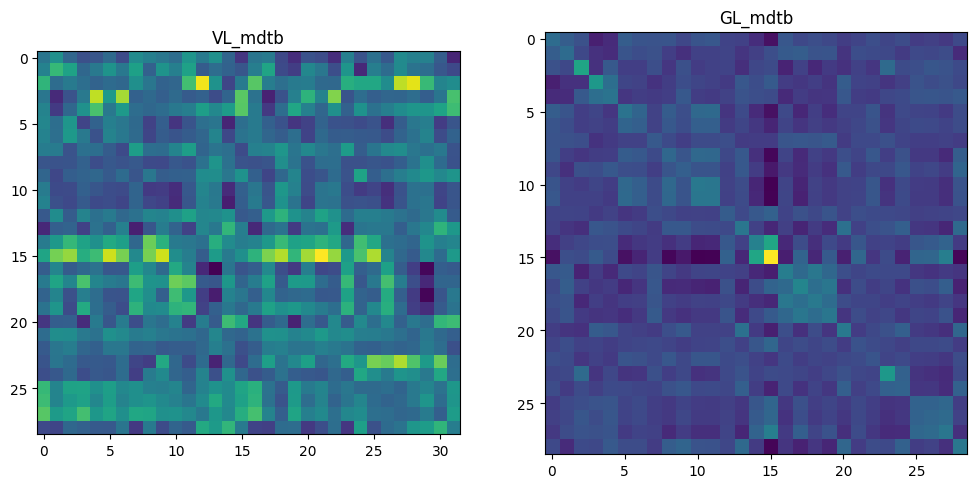

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].imshow(VL_mdtb)
ax[0].set_title('VL_mdtb')

ax[1].imshow(GL_mdtb)
ax[1].set_title('GL_mdtb')

plt.show()

In [14]:
cond_vec = np.tile(np.arange(1, 8 + 1), 1)
part_vec = np.repeat(np.arange(1, 1 + 1), 8)

In [6]:
def HBP_u(train_data,cond_vec,part_vec,full_model):
    model = full_model 
    sym_type = 'sym'
    ar_model = model.arrange
    ar_model.logpi = pt.tensor(ar_model.logpi, dtype=pt.get_default_dtype())
    x_matrix = indicator(cond_vec)
    
    
    em_model = em.MixVMF(K=32, P=18290, X=x_matrix, part_vec=part_vec,
                         subject_specific_kappa=False, parcel_specific_kappa=False, 
                         subjects_equal_weight=True)
    
    M_1 = fm.FullMultiModel(arrange=ar_model, emission=[em_model])
    M_1.initialize([train_data])

    M_1, ll,_,U_individual = M_1.fit_em(iter=200, tol=0.01,
                                     fit_arrangement=False,
                                     fit_emission= True,
                                     first_evidence=False)    

    # Get the data-only parcellation
    emloglik = M_1.emissions[0].Estep()
    U_data = pt.softmax(emloglik, dim=1) # get data only parcellation

    return U_data

In [25]:
def evaluate_cos(D,ytrain,Vs,ytest,vtest,M):
    for i, row in D.iterrows():
        print(i)
        task_subset_indices = row['combination']
        V_subset = Vs[task_subset_indices, :]
        
        # Subtract mean across rows
        V_subset = V_subset - np.mean(V_subset, axis=0)
        
        # Generate the data Y from U_true and V_subset
        y_subset = ytrain[:,task_subset_indices, :]

        # Estimate U_hat using OLS
        # U_hat_ols = sim.estimate_Us_ols(y_subset, V_subset)
        # U_hat_NNLS = sim.estimate_Us_NNLS(y_subset, V_subset)    

        # make into tensores
        ytest = pt.tensor(ytest,dtype=pt.float32)
        vtest = pt.tensor(vtest,dtype=pt.float32)
        # U_hat_ols = pt.tensor(U_hat_ols,dtype=pt.float32)
        # U_hat_NNLS = pt.tensor(U_hat_NNLS,dtype=pt.float32)
        U_hat_HBP = [HBP_u(y_subset,cond_vec,part_vec,full_model)]
        

        # cos_ols = ev.coserr(ytest,vtest,U_hat_ols).mean().numpy()
        # cos_NNLS = ev.coserr(ytest,vtest,U_hat_NNLS).mean().numpy()
        cos_HBP = calc_test_error(M=M,tdata=ytest,U_hats=U_hat_HBP,fit_emission='use_Uhats').mean()
        

        # Pindiv = pt.argmax(U_hat_HBP, dim=1) + 1
        # dcbc_indiv = calc_test_dcbc(Pindiv, ytest, dist)

        # D.at[i, 'cos_ols'] = cos_ols
        # D.at[i, 'cos_NNLS'] = cos_NNLS
        D.at[i, 'cos_HBP'] = cos_HBP
        # D.at[i, 'dcbc_indiv'] = dcbc_indiv


    return D

In [9]:
MDTB_dataset = DataSetMDTB('/cifs/diedrichsen/data/FunctionalFusion/MDTB')
if not os.path.exists('/cifs/diedrichsen/data/FunctionalFusion/MDTB'):
    MDTB_dataset = DataSetMDTB('Y:/data/FunctionalFusion/MDTB')
data_mdtb_s1_All,info_mdtb_1_All  =MDTB_dataset.get_data(space='MNISymC2',ses_id='ses-s1',type='CondAll')
data_mdtb_s1_All[np.isnan(data_mdtb_s1_All)] = 0

In [10]:
MDTB_dataset = DataSetMDTB('/cifs/diedrichsen/data/FunctionalFusion/MDTB')
if not os.path.exists('/cifs/diedrichsen/data/FunctionalFusion/MDTB'):
    MDTB_dataset = DataSetMDTB('Y:/data/FunctionalFusion/MDTB')
data_mdtb_s2_All,info_mdtb_2_All  =MDTB_dataset.get_data(space='MNISymC2',ses_id='ses-s2',type='CondAll')
data_mdtb_s2_All[np.isnan(data_mdtb_s2_All)] = 0

In [15]:
cond_vec_test = np.tile(np.arange(1, 32 + 1), 1)
part_vec_test = np.repeat(np.arange(1, 1 + 1), 32)

model = full_model 
sym_type = 'sym'
ar_model = model.arrange
ar_model.logpi = pt.tensor(ar_model.logpi, dtype=pt.get_default_dtype())
x_matrix = indicator(cond_vec_test)


em_model = em.MixVMF(K=32, P=18290, X=x_matrix, part_vec=part_vec_test,
                    subject_specific_kappa=False, parcel_specific_kappa=False, 
                    subjects_equal_weight=True)

M_2 = fm.FullMultiModel(arrange=ar_model, emission=[em_model])
M_2.initialize([data_mdtb_s2_All])

M_2, ll,_,U_individual = M_2.fit_em(iter=200, tol=0.01,
                                fit_arrangement=False,
                                fit_emission= True,
                                first_evidence=False)    


/tmp/ipykernel_106106/14011292.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ar_model.logpi = pt.tensor(ar_model.logpi, dtype=pt.get_default_dtype())


Likelihood decreased - terminating on iteration 93


In [26]:
D_mdtb = ut.build_combinations(GL_mdtb, strategy='random',n_iter=400,n_tasks=8,seed=10)
A_mdtb = D_mdtb[D_mdtb['offset'] == 0.001]
A_mdtb = evaluate_cos(A_mdtb, data_mdtb_s1_All,VL_mdtb, data_mdtb_s2_All, VL_mdtb_2,M_2)



1


/tmp/ipykernel_106106/2901817201.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ar_model.logpi = pt.tensor(ar_model.logpi, dtype=pt.get_default_dtype())


Likelihood decreased - terminating on iteration 77
Subject:0:0.1076s
Subject:1:0.1603s
Subject:2:0.1230s
Subject:3:0.1251s
Subject:4:0.1100s
Subject:5:0.1166s
Subject:6:0.1112s
Subject:7:0.1307s
Subject:8:0.1143s
Subject:9:0.1269s
Subject:10:0.1139s
Subject:11:0.1547s
Subject:12:0.1040s
Subject:13:0.1377s
Subject:14:0.1239s
Subject:15:0.1277s
Subject:16:0.1018s
Subject:17:0.1173s
Subject:18:0.1375s
Subject:19:0.1123s
Subject:20:0.1305s
Subject:21:0.1286s
Subject:22:0.1701s
Subject:23:0.1552s
4


/tmp/ipykernel_106106/98695565.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  D.at[i, 'cos_HBP'] = cos_HBP
/tmp/ipykernel_106106/98695565.py:18: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ytest = pt.tensor(ytest,dtype=pt.float32)
/tmp/ipykernel_106106/98695565.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  vtest = pt.tensor(vtest,dtype=pt.float32)
/tmp/ipykernel_106106/2901817201.py:5: UserWarning: To copy construct from a tensor, it

Subject:0:0.1283s
Subject:1:0.1727s
Subject:2:0.1133s
Subject:3:0.1375s
Subject:4:0.1141s
Subject:5:0.1695s
Subject:6:0.1148s
Subject:7:0.1362s
Subject:8:0.1344s
Subject:9:0.1334s
Subject:10:0.1129s
Subject:11:0.1336s
Subject:12:0.1295s
Subject:13:0.1331s
Subject:14:0.1218s
Subject:15:0.1712s
Subject:16:0.1207s
Subject:17:0.1510s
Subject:18:0.1250s
Subject:19:0.1180s
Subject:20:0.1799s
Subject:21:0.1307s
Subject:22:0.1070s
Subject:23:0.1149s
7
Likelihood decreased - terminating on iteration 65
Subject:0:0.1724s
Subject:1:0.2474s
Subject:2:0.1524s
Subject:3:0.1704s
Subject:4:0.1443s
Subject:5:0.2274s
Subject:6:0.1452s
Subject:7:0.1588s
Subject:8:0.1543s
Subject:9:0.1507s
Subject:10:0.1226s
Subject:11:0.2031s
Subject:12:0.1300s
Subject:13:0.1480s
Subject:14:0.1379s
Subject:15:0.1538s
Subject:16:0.1252s
Subject:17:0.1562s
Subject:18:0.1353s
Subject:19:0.2224s
Subject:20:0.1997s
Subject:21:0.1679s
Subject:22:0.1253s
Subject:23:0.1658s
10
Subject:0:0.1001s
Subject:1:0.1889s
Subject:2:0.1070

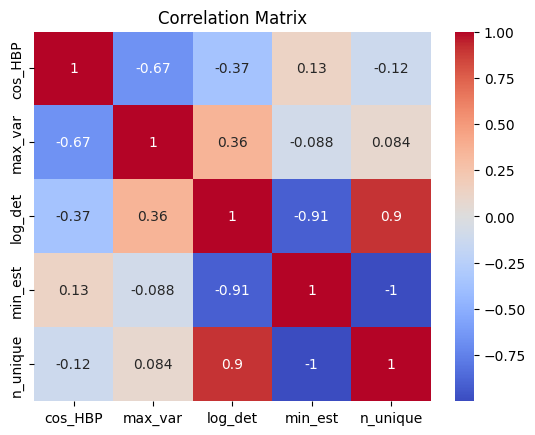

In [27]:
# Correlation heatmap
corr_matrix = A_mdtb[['cos_HBP','max_var', 'log_det', 'min_est','n_unique']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()